# Matplotlib for Machine Learning

This notebook is a practical Matplotlib guide for machine learning students.

By the end of this notebook, you should be comfortable with:

- figures and axes
- line, scatter, bar, histogram, box, and image plots
- titles, labels, legends, grids, ticks, limits, and styles
- subplots and layout control
- annotations and colorbars
- daily-use ML charts such as loss curves, feature plots, distributions, and confusion matrices

You do **not** need every corner of Matplotlib for a machine learning course.
You need the parts you will use repeatedly in assignments, projects, and model evaluation.


## 1. Setup

`matplotlib.pyplot` gives a simple plotting interface.
`numpy` helps us generate and manage numeric data.

Most professional plotting is done with this pattern:

```python
fig, ax = plt.subplots()
ax.plot(...)
plt.show()
```

Here:

- `fig` means the full figure or canvas
- `ax` means one plot area inside the figure


In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")
np.random.seed(42)


## 2. Your Most Important Template

This is the single most useful Matplotlib pattern to memorize.


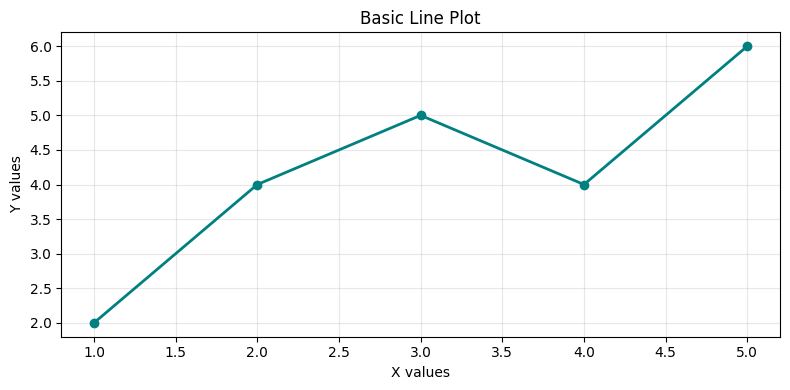

In [3]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 6])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, marker="o", linewidth=2, color="teal")
ax.set_title("Basic Line Plot")
ax.set_xlabel("X values")
ax.set_ylabel("Y values")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. `pyplot` vs Object-Oriented Style

You may see both styles.

`pyplot` style:

```python
plt.plot(x, y)
plt.title("Plot")
plt.show()
```

Object-oriented style:

```python
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_title("Plot")
plt.show()
```

For ML work, prefer the object-oriented style because it scales better when you use multiple subplots.


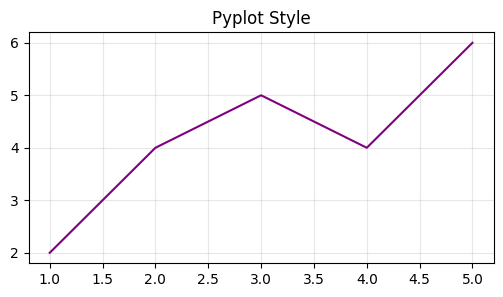

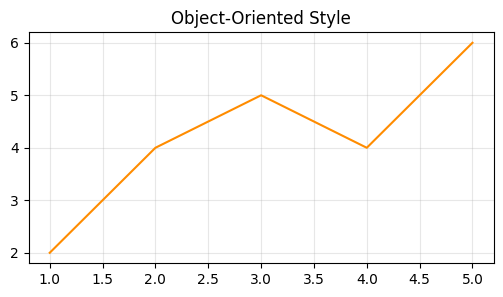

In [4]:
# Pyplot style
plt.figure(figsize=(6, 3))
plt.plot(x, y, color="purple")
plt.title("Pyplot Style")
plt.grid(True, alpha=0.3)
plt.show()

# Object-oriented style
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x, y, color="darkorange")
ax.set_title("Object-Oriented Style")
ax.grid(True, alpha=0.3)
plt.show()


## 4. Line Plot

Use line plots for:

- training loss
- validation loss
- accuracy over epochs
- trends over time

Common methods and arguments:

- `ax.plot(x, y)`
- `color=`
- `linestyle=`
- `linewidth=`
- `marker=`
- `label=`
- `alpha=`


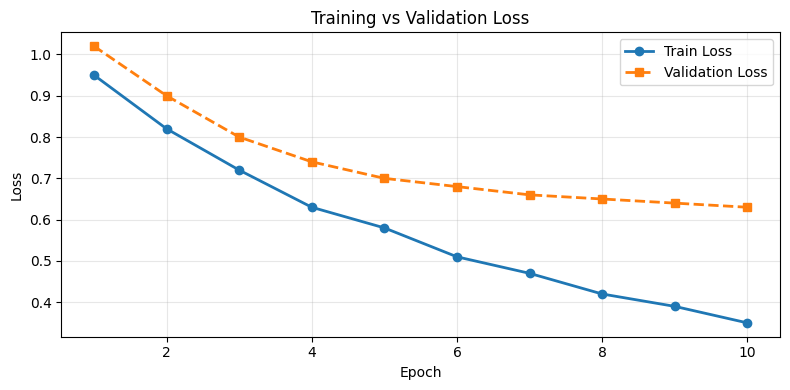

In [5]:
epochs = np.arange(1, 11)
train_loss = np.array([0.95, 0.82, 0.72, 0.63, 0.58, 0.51, 0.47, 0.42, 0.39, 0.35])
val_loss = np.array([1.02, 0.90, 0.80, 0.74, 0.70, 0.68, 0.66, 0.65, 0.64, 0.63])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, train_loss, marker="o", linewidth=2, label="Train Loss")
ax.plot(epochs, val_loss, marker="s", linestyle="--", linewidth=2, label="Validation Loss")
ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Scatter Plot

Use scatter plots for:

- relationship between two features
- cluster visualization
- actual vs predicted values
- outlier checking

Main method:

- `ax.scatter(x, y)`


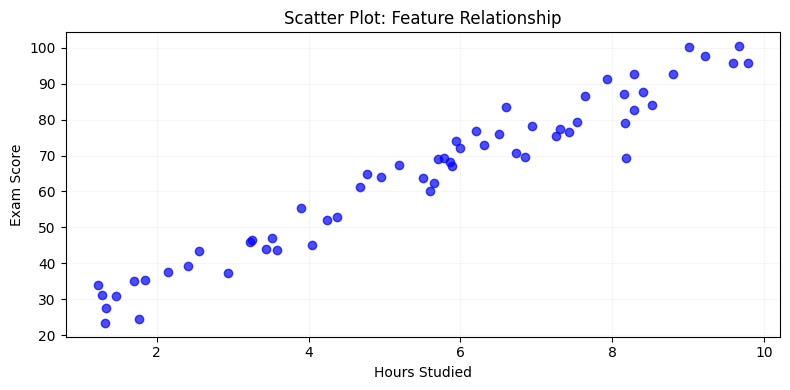

In [ ]:
hours_studied = np.random.uniform(1, 10, 60)
exam_score = 8 * hours_studied + np.random.normal(0, 5, 60) + 20

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(hours_studied, exam_score, color="blue", alpha=0.7)
ax.set_title("Scatter Plot: Feature Relationship")
ax.set_xlabel("Hours Studied")
ax.set_ylabel("Exam Score")
ax.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()


## 6. Bar Plot

Use bar plots for:

- comparing model performance
- showing category counts
- comparing feature importances


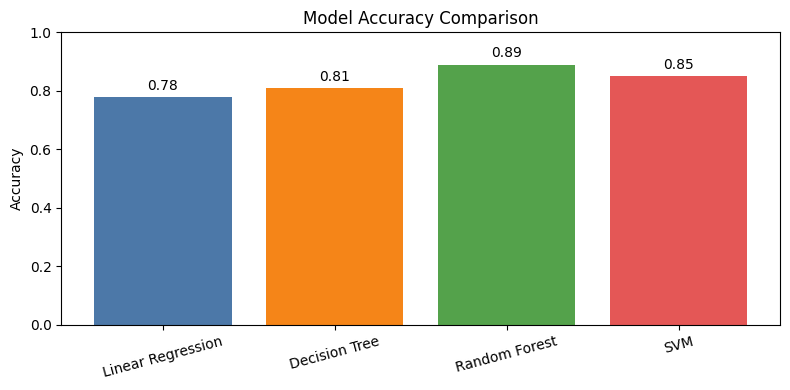

In [9]:
models = ["Linear Regression", "Decision Tree", "Random Forest", "SVM"]
scores = [0.78, 0.81, 0.89, 0.85]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(models, scores, color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
ax.set_title("Model Accuracy Comparison")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


## 7. Histogram

Use histograms for:

- checking data distribution
- identifying skewness
- understanding spread of values

Main method:

- `ax.hist(data, bins=...)`


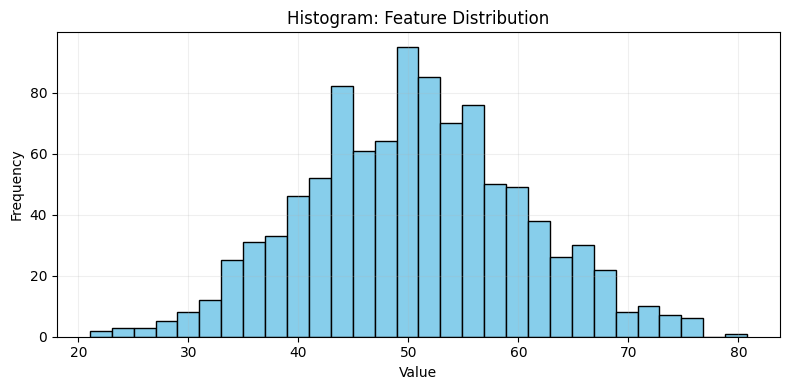

In [10]:
feature_values = np.random.normal(loc=50, scale=10, size=1000)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(feature_values, bins=30, color="skyblue", edgecolor="black")
ax.set_title("Histogram: Feature Distribution")
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## 8. Box Plot

Use box plots for:

- spotting outliers
- comparing spread between groups
- understanding median and quartiles


C:\Users\Rineeth\AppData\Local\Temp\ipykernel_23492\3396582675.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([group_a, group_b, group_c], labels=["Group A", "Group B", "Group C"])


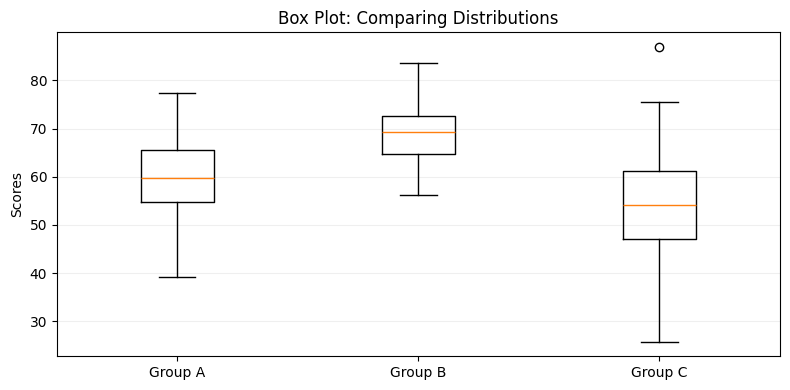

In [11]:
group_a = np.random.normal(60, 8, 100)
group_b = np.random.normal(68, 6, 100)
group_c = np.random.normal(55, 10, 100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([group_a, group_b, group_c], labels=["Group A", "Group B", "Group C"])
ax.set_title("Box Plot: Comparing Distributions")
ax.set_ylabel("Scores")
ax.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## 9. Images with `imshow()`

This is very important in machine learning for:

- image data
- heatmaps
- correlation matrices
- confusion matrices


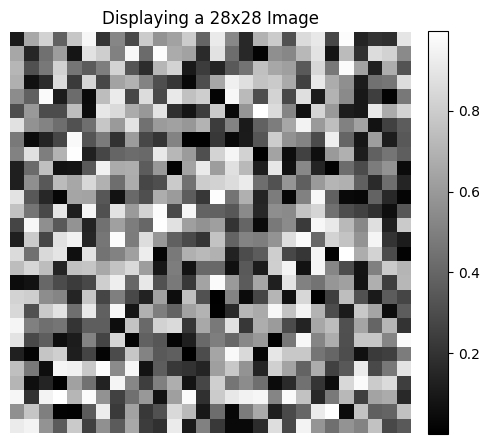

In [12]:
image = np.random.rand(28, 28)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(image, cmap="gray")
ax.set_title("Displaying a 28x28 Image")
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 10. Titles, Labels, Legends, and Grid

These are used almost every day.

Methods:

- `ax.set_title()`
- `ax.set_xlabel()`
- `ax.set_ylabel()`
- `ax.legend()`
- `ax.grid()`


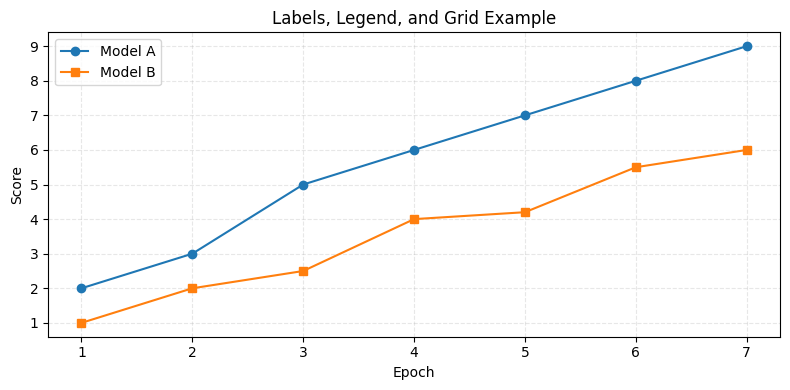

In [13]:
x = np.arange(1, 8)
y1 = np.array([2, 3, 5, 6, 7, 8, 9])
y2 = np.array([1, 2, 2.5, 4, 4.2, 5.5, 6])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y1, marker="o", label="Model A")
ax.plot(x, y2, marker="s", label="Model B")
ax.set_title("Labels, Legend, and Grid Example")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Axis Limits, Ticks, and Tick Rotation

Useful methods:

- `ax.set_xlim()`
- `ax.set_ylim()`
- `ax.set_xticks()`
- `ax.set_yticks()`
- `ax.tick_params()`


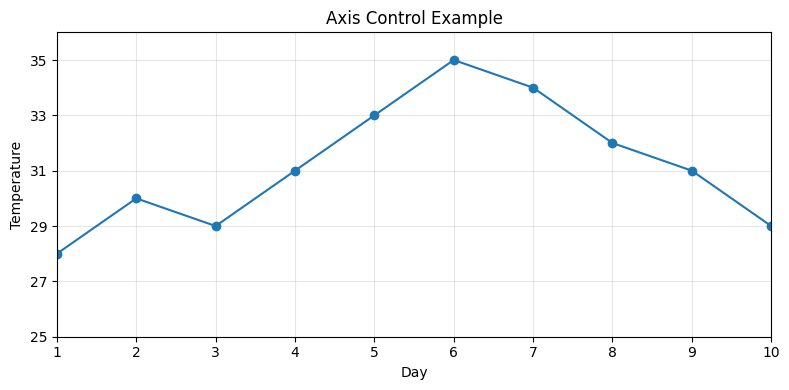

In [14]:
days = np.arange(1, 11)
temperature = np.array([28, 30, 29, 31, 33, 35, 34, 32, 31, 29])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(days, temperature, marker="o")
ax.set_title("Axis Control Example")
ax.set_xlabel("Day")
ax.set_ylabel("Temperature")
ax.set_xlim(1, 10)
ax.set_ylim(25, 36)
ax.set_xticks(days)
ax.set_yticks(np.arange(25, 37, 2))
ax.tick_params(axis="x", rotation=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Subplots

Subplots help when you want multiple charts in one figure.

Main method:

```python
fig, ax = plt.subplots(rows, cols, figsize=(width, height))
```


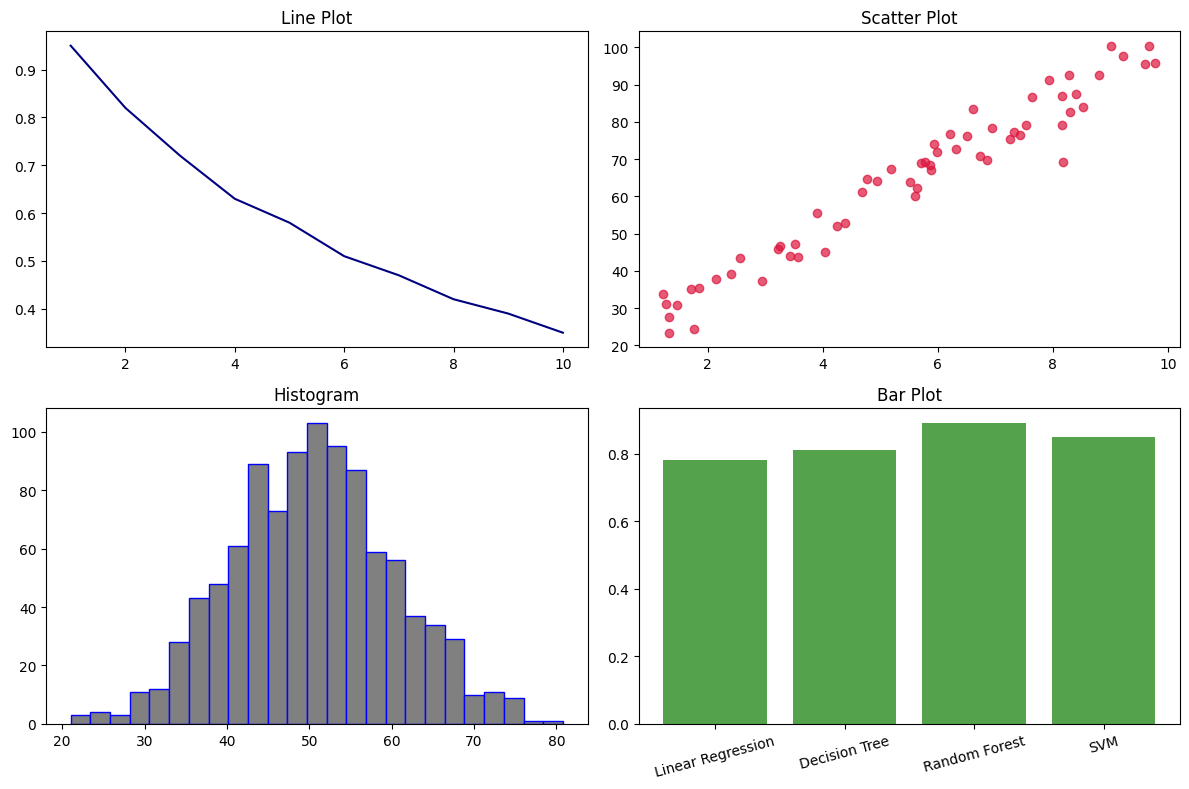

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(epochs, train_loss, color="navy")
ax[0, 0].set_title("Line Plot")

ax[0, 1].scatter(hours_studied, exam_score, color="crimson", alpha=0.7)
ax[0, 1].set_title("Scatter Plot")

ax[1, 0].hist(feature_values, bins=25, color="grey", edgecolor="blue")
ax[1, 0].set_title("Histogram")

ax[1, 1].bar(models, scores, color="#54A24B")
ax[1, 1].set_title("Bar Plot")
ax[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


## 13. Style, Color, and Figure Size

Useful tools:

- `plt.style.use(...)`
- `figsize=(w, h)`
- `color=`
- `alpha=`
- `linestyle=`
- `marker=`


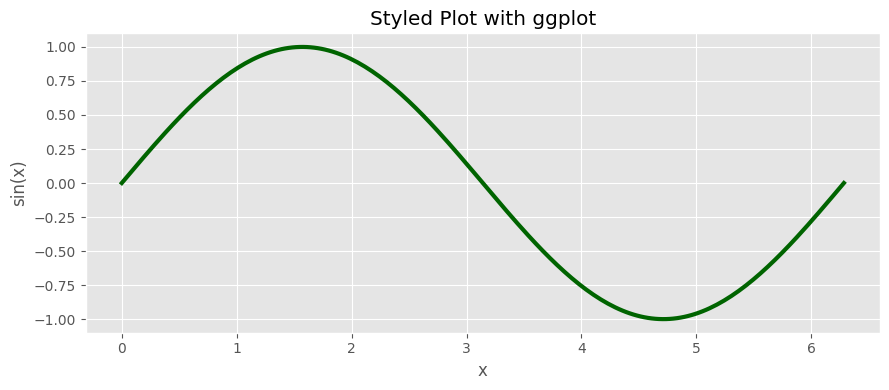

In [18]:
plt.style.use("ggplot")

x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, y, color="darkgreen", linewidth=3, linestyle="-", marker=None)
ax.set_title("Styled Plot with ggplot")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
plt.tight_layout()
plt.show()

plt.style.use("default")


## 14. Annotation and Text

Useful methods:

- `ax.text()`
- `ax.annotate()`


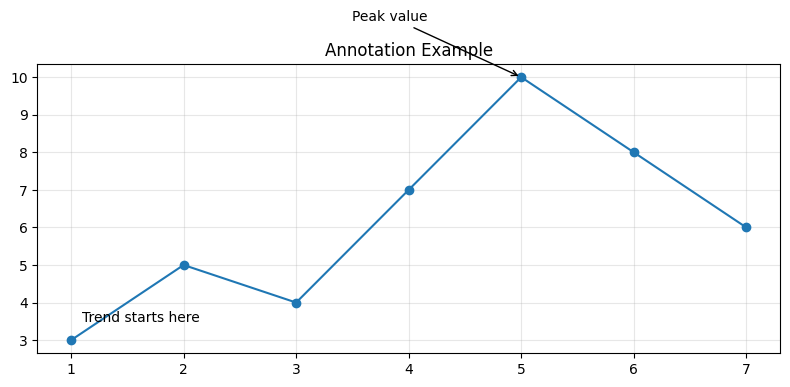

In [19]:
x = np.arange(1, 8)
y = np.array([3, 5, 4, 7, 10, 8, 6])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, marker="o")
peak_index = np.argmax(y)
peak_x = x[peak_index]
peak_y = y[peak_index]

ax.annotate(
    "Peak value",
    xy=(peak_x, peak_y),
    xytext=(peak_x - 1.5, peak_y + 1.5),
    arrowprops=dict(arrowstyle="->", color="black")
)
ax.text(1.1, 3.5, "Trend starts here")
ax.set_title("Annotation Example")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Confusion Matrix Style Plot

This is a very common ML visualization.


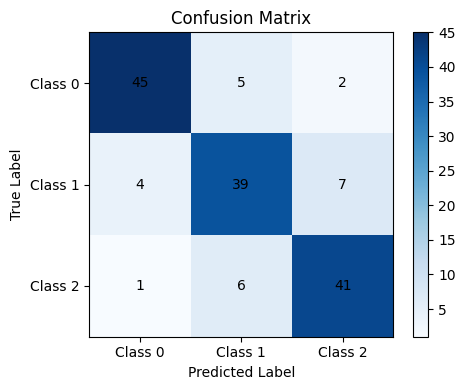

In [20]:
cm = np.array([
    [45, 5, 2],
    [4, 39, 7],
    [1, 6, 41]
])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["Class 0", "Class 1", "Class 2"])
ax.set_yticklabels(["Class 0", "Class 1", "Class 2"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 16. Actual vs Predicted Plot

Helpful for regression tasks.


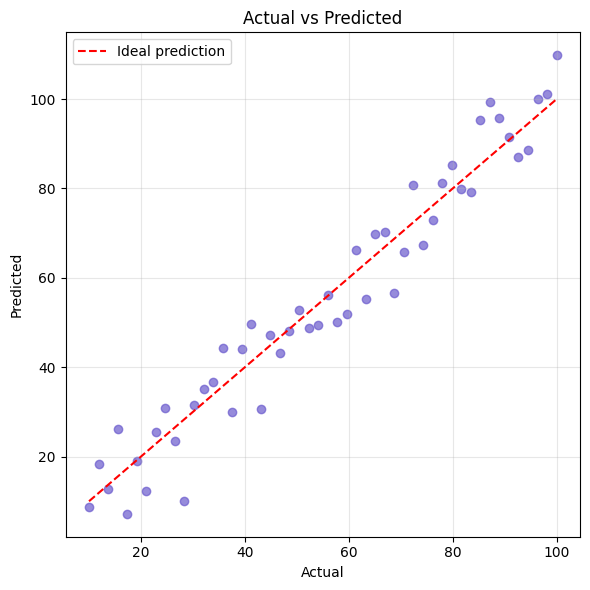

In [21]:
actual = np.linspace(10, 100, 50)
predicted = actual + np.random.normal(0, 7, 50)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(actual, predicted, alpha=0.7, color="slateblue")
ax.plot([10, 100], [10, 100], color="red", linestyle="--", label="Ideal prediction")
ax.set_title("Actual vs Predicted")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 17. Save Figures

Use this when you need plots in reports, assignments, or presentations.

```python
fig.savefig("plot.png", dpi=300, bbox_inches="tight")
```


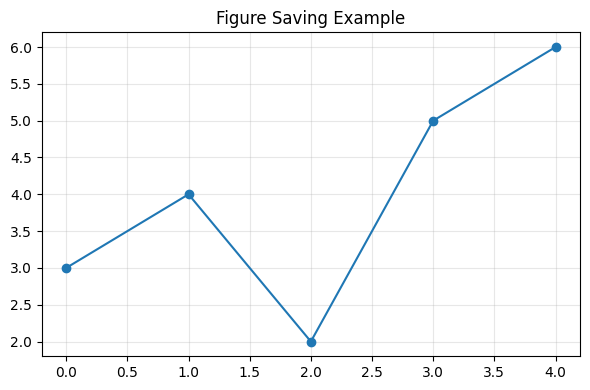

In [22]:
x = np.arange(5)
y = np.array([3, 4, 2, 5, 6])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, marker="o")
ax.set_title("Figure Saving Example")
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Uncomment the next line to save the image file.
# fig.savefig("my_plot.png", dpi=300, bbox_inches="tight")

plt.show()


## 18. Daily-Use Methods Cheat Sheet

Methods you will use very often:

- `plt.subplots()`
- `plt.show()`
- `plt.tight_layout()`
- `plt.style.use()`
- `ax.plot()`
- `ax.scatter()`
- `ax.bar()`
- `ax.hist()`
- `ax.boxplot()`
- `ax.imshow()`
- `ax.set_title()`
- `ax.set_xlabel()`
- `ax.set_ylabel()`
- `ax.legend()`
- `ax.grid()`
- `ax.set_xlim()`
- `ax.set_ylim()`
- `ax.set_xticks()`
- `ax.set_yticks()`
- `ax.tick_params()`
- `ax.text()`
- `ax.annotate()`
- `fig.colorbar()`
- `fig.savefig()`


## 19. Practice Tasks

Try these on your own:

1. Make a loss vs epoch line chart with two lines.
2. Create a histogram for 500 random normal values.
3. Compare 4 model accuracies in a bar chart.
4. Display a 10x10 random matrix using `imshow()`.
5. Build a `2 x 2` subplot figure with line, scatter, histogram, and bar plots.
6. Add labels, legends, and grid to every plot.
7. Annotate the highest point in a line chart.


## 20. Final Summary

For machine learning, you do not need all of Matplotlib.

You should become very comfortable with:

- line plots
- scatter plots
- histograms
- bar charts
- box plots
- images and heatmaps
- labels, legends, and grid
- subplots
- saving figures

If you can build these without looking up syntax every time, you are already strong enough for most ML coursework.
